In [11]:
import pandas as pd
train = pd.read_csv('../data/train_cleaned.csv', parse_dates=['date'])

In [15]:
cat_features = ['store', 'item', 'day_of_week', 'month', 'year', 'is_holiday', 'is_shopping_day']
FEATURES = cat_features + ['sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7', "sales_rolling_mean_30", "sales_lag_30"]

Строим CatBoost бустинг над деревьями, если это не Н день, то для предсказания покупок используем предсказание модели

In [19]:
def recursive_forecast_month(model, history_df, forecast_dates_df):
    """
    Версия с поддержкой MultiQuantile (3 колонки прогноза).
    """
    # Рабочий буфер: история продаж
    buffer = history_df[["date", "store", "item", "sales"]].copy()
    
    # Уникальные пары магазин-товар
    pairs = forecast_dates_df[["store", "item"]].drop_duplicates()
    results = []
    forecast_days = sorted(forecast_dates_df["date"].unique())

    for day in forecast_days:
        day_rows = forecast_dates_df[forecast_dates_df["date"] == day].copy()

        # ── Пересчитываем лаги вручную ──────────────────────────────────────
        cutoff_date = day - pd.Timedelta(days=31)
        recent = buffer[buffer["date"] >= cutoff_date].copy()

        lag_rows = []
        for _, pair_row in pairs.iterrows():
            s, i = pair_row["store"], pair_row["item"]
            hist = recent[(recent["store"] == s) & (recent["item"] == i)].sort_values("date")
            
            # Вспомогательная функция для лага
            def get_lag(n):
                target = day - pd.Timedelta(days=n)
                val = hist[hist["date"] == target]["sales"].values
                return val[0] if len(val) > 0 else np.nan

            l1, l7, l30 = get_lag(1), get_lag(7), get_lag(30)
            
            # Rolling mean
            w7 = hist[(hist["date"] >= day - pd.Timedelta(days=7)) & (hist["date"] < day)]["sales"].values
            w30 = hist[(hist["date"] >= day - pd.Timedelta(days=30)) & (hist["date"] < day)]["sales"].values
            
            lag_rows.append({
                "store": s, "item": i,
                "sales_lag_1": l1, "sales_lag_7": l7, "sales_lag_30": l30,
                "sales_rolling_mean_7": np.mean(w7) if len(w7) > 0 else np.nan,
                "sales_rolling_mean_30": np.mean(w30) if len(w30) > 0 else np.nan
            })

        lag_df = pd.DataFrame(lag_rows)
        day_rows = day_rows.merge(lag_df, on=["store", "item"], how="left")

        # ── ПРЕДСКАЗАНИЕ (Здесь была ошибка!) ───────────────────────────────
        X_day = day_rows[FEATURES]
        preds = model.predict(X_day) # Теперь это (N, 3)
        preds = np.maximum(preds, 0)

        day_rows = day_rows.copy()
        # Раскладываем 3 колонки квантилей
        day_rows["lower_ci"] = preds[:, 0]       # q=0.05
        day_rows["predicted_sales"] = preds[:, 1] # q=0.50 (медиана)
        day_rows["upper_ci"] = preds[:, 2]       # q=0.95

        # ── Обновляем буфер МЕДИАНОЙ ────────────────────────────────────────
        pred_buffer = day_rows[["date", "store", "item"]].copy()
        pred_buffer["sales"] = preds[:, 1] # Для лагов используем медиану
        buffer = pd.concat([buffer, pred_buffer], ignore_index=True)

        results.append(day_rows)

    return pd.concat(results, ignore_index=True)

In [20]:
def add_lag_features(df):
    df = df.copy()
    # Создаем лаги (продажи N дней назад)
    df['sales_lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
    df['sales_lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
    df['sales_lag_30'] = df.groupby(['store', 'item'])['sales'].shift(30)
    
    # Создаем скользящие средние (среднее за последние N дней)
    # Используем shift(1), чтобы не было утечки данных (не смотреть в сегодня при прогнозе на сегодня)
    df['sales_rolling_mean_7'] = df.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )
    df['sales_rolling_mean_30'] = df.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.shift(1).rolling(window=30).mean()
    )
    return df

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns



# Выбираем последнюю точку для теста (декабрь 2017)
cutoff = train["date"].max() - pd.DateOffset(days=30) 
cutoff = cutoff.replace(day=1) # Округляем до начала месяца

print(f"Запуск...")
print(f"Train: до {cutoff.date()} | Test: Декабрь 2017")

# 1. Разделение
train_fold = train[train["date"] < cutoff].copy()
test_fold = train[train["date"] >= cutoff].copy()

# 2. Пересчет признаков (Честная статика)
cols_to_drop = ["store_avg_sales", "item_avg_sales", "sales_lag_1", "sales_lag_7", 
                "sales_lag_30", "sales_rolling_mean_7", "sales_rolling_mean_30"]

train_fold = train_fold.drop(columns=[c for c in cols_to_drop if c in train_fold.columns])
test_fold = test_fold.drop(columns=[c for c in cols_to_drop if c in test_fold.columns])

s_avg = train_fold.groupby("store")["sales"].mean().rename("store_avg_sales")
i_avg = train_fold.groupby("item")["sales"].mean().rename("item_avg_sales")

train_fold = train_fold.join(s_avg, on="store").join(i_avg, on="item")
test_fold = test_fold.join(s_avg, on="store").join(i_avg, on="item")

# Лаги для обучения
train_fold = add_lag_features(train_fold).dropna()

In [ ]:


# 3. Обучение
X_tr, y_tr = train_fold[FEATURES], train_fold["sales"]
val_cutoff = cutoff - pd.DateOffset(months=1)
X_val = train_fold[train_fold["date"] >= val_cutoff][FEATURES]
y_val = train_fold[train_fold["date"] >= val_cutoff]["sales"]

model = CatBoostRegressor(
    iterations=1000,
    # Мы ставим 0.6 как "базовый" прогноз (медиану), чтобы модель была чуть оптимистичнее
    # И 0.98 для верхней границы, чтобы почти исключить дефицит
    loss_function='MultiQuantile:alpha=0.05,0.6,0.98', 
    verbose=0
)

model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

# 4. Рекурсивный прогноз
history = train_fold[["date", "store", "item", "sales"]].copy()
forecast_df = recursive_forecast_month(model, history, test_fold)

# 5. Метрики (с исправлением MAPE)
y_true = forecast_df["sales"]
y_pred = forecast_df["predicted_sales"]

m_mae = mean_absolute_error(y_true, y_pred)
m_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Заменяем MAPE на "безопасный" вариант, чтобы не делить на 0
m_mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100 

print(f"\nРезультаты фолда:")
print(f"MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | MAPE: {m_mape:.2f}%")

# ─────────────────────────────────────────────


Запуск...
Train: до 2017-12-01 | Test: Декабрь 2017

Результаты фолда:
MAE: 6.83 | RMSE: 8.63 | MAPE: 19.09%


## Визуализация


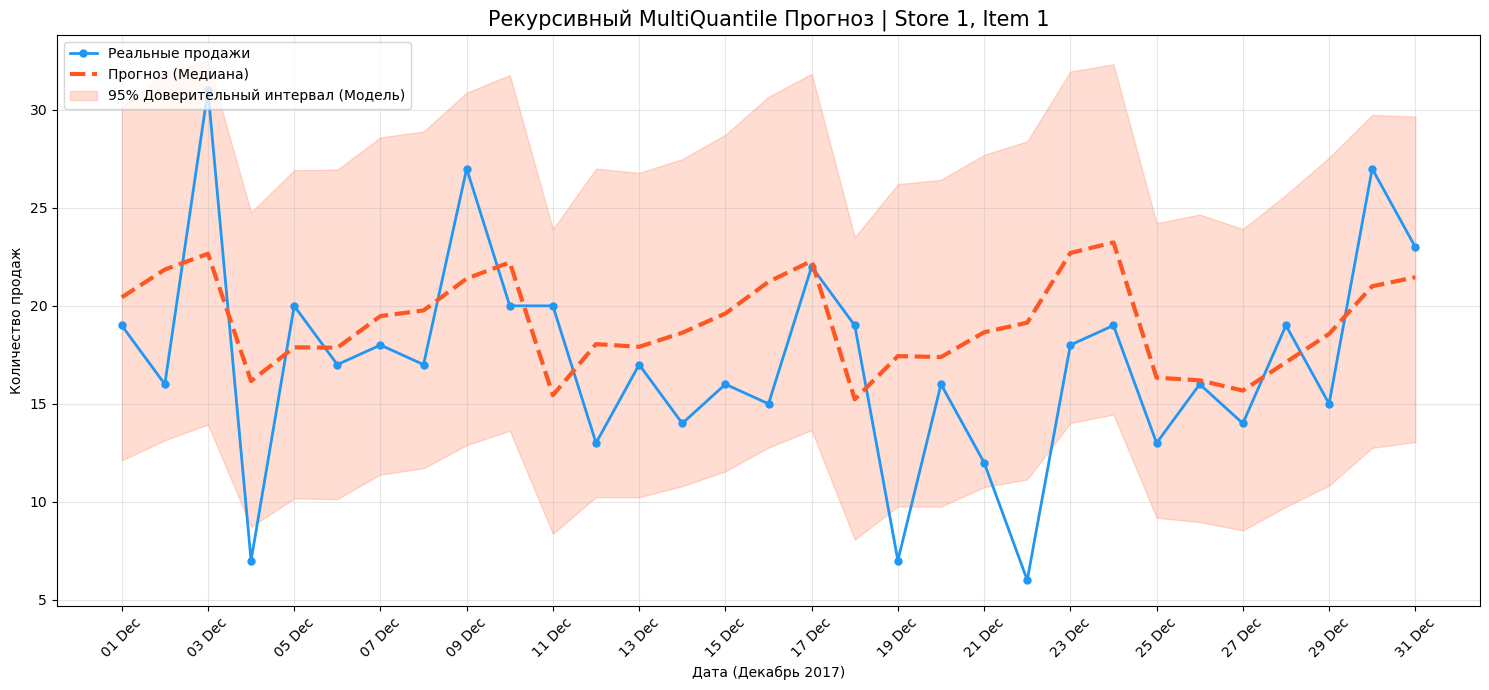

In [22]:
# 1. Выбираем конкретную пару для детального осмотра
SAMPLE_STORE = 1
SAMPLE_ITEM = 1

sample = forecast_df[
    (forecast_df["store"] == SAMPLE_STORE) & 
    (forecast_df["item"] == SAMPLE_ITEM)
].sort_values("date")

# 2. Строим график
plt.figure(figsize=(15, 7))

# Реальные данные (Синие точки)
plt.plot(sample["date"], sample["sales"], 
         label="Реальные продажи", color="#2196F3", lw=2, marker='o', markersize=5)

# Предсказание медианы (Оранжевая пунктирная линия)
plt.plot(sample["date"], sample["predicted_sales"], 
         label="Прогноз (Медиана)", color="#FF5722", lw=3, ls="--")

# ДИНАМИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (MultiQuantile)
plt.fill_between(
    sample["date"], 
    sample["lower_ci"], 
    sample["upper_ci"], 
    color='#FF5722', alpha=0.2, 
    label="95% Доверительный интервал (Модель)"
)

# Оформление
plt.title(f"Рекурсивный MultiQuantile Прогноз | Store {SAMPLE_STORE}, Item {SAMPLE_ITEM}", fontsize=15)
plt.xlabel("Дата (Декабрь 2017)")
plt.ylabel("Количество продаж")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

# Настройка оси X для дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Модель пополнения склада

In [26]:
def calculate_business_metrics(df, model_name):
    # Допустим, верхняя граница (upper_ci) — это то, сколько мы завезли на склад
    stock_level = df["upper_ci"]
    actual_sales = df["sales"]
    
    # 1. Упущенные продажи (Demand > Stock)
    lost_sales = np.maximum(0, actual_sales - stock_level).sum()
    
    # 2. Излишки (Stock > Demand)
    # Это товары, которые остались лежать на полке в конце дня
    excess_stock = np.maximum(0, stock_level - actual_sales).sum()
    
    # 3. Сервис-левел (какой % спроса мы удовлетворили)
    service_level = (actual_sales.sum() - lost_sales) / actual_sales.sum() * 100
    
    return {
        "Модель": model_name,
        "Упущено продаж (шт)": int(lost_sales),
        "Затоваривание склада (шт)": int(excess_stock),
        "Service Level (%)": f"{service_level:.2f}%"
    }



In [31]:
def calculate_business_metrics(df, model_name):
    # Допустим, верхняя граница (upper_ci) — это то, сколько мы завезли на склад
    stock_level = df["upper_ci"]
    actual_sales = df["sales"]
    
    # 1. Упущенные продажи (Demand > Stock)
    lost_sales = np.maximum(0, actual_sales - stock_level).sum()
    
    # 2. Излишки (Stock > Demand)
    # Это товары, которые остались лежать на полке в конце дня
    excess_stock = np.maximum(0, stock_level - actual_sales).sum()
    
    # 3. Сервис-левел (какой % спроса мы удовлетворили)
    service_level = (actual_sales.sum() - lost_sales) / actual_sales.sum() * 100
    
    return {
        "Модель": model_name,
        "Упущено продаж (шт)": int(lost_sales),
        "Затоваривание склада (шт)": int(excess_stock),
        "Service Level (%)": f"{service_level:.2f}%"
    }




In [33]:
# Считаем для нашей текущей MultiQuantile модели
mq_metrics = calculate_business_metrics(forecast_df, "MultiQuantile (Динамическая)")

# Посчитаем среднюю ширину интервала MultiQuantile, 
# чтобы понять, сколько "в среднем" модель добавляет сверху
avg_mq_safety_buffer = (forecast_df["upper_ci"] - forecast_df["predicted_sales"]).mean()

print(f"Средний 'умный' запас MultiQuantile: {avg_mq_safety_buffer:.2f} шт.")

# Теперь создадим модель, которая ВСЕГДА прибавляет именно это число
df_fair_static = forecast_df.copy()
df_fair_static["upper_ci"] = df_fair_static["predicted_sales"] + avg_mq_safety_buffer

fair_metrics = calculate_business_metrics(df_fair_static, f"Честный статик (+{avg_mq_safety_buffer:.1f})")
print("\n=== СРАВНЕНИЕ С ЧЕСТНЫМ ЗАПАСОМ ===")
print(pd.DataFrame([mq_metrics, fair_metrics]).to_string(index=False))

Средний 'умный' запас MultiQuantile: 14.27 шт.

=== СРАВНЕНИЕ С ЧЕСТНЫМ ЗАПАСОМ ===
                      Модель  Упущено продаж (шт)  Затоваривание склада (шт) Service Level (%)
MultiQuantile (Динамическая)                  563                     284198            99.92%
      Честный статик (+14.3)                 1116                     284750            99.84%


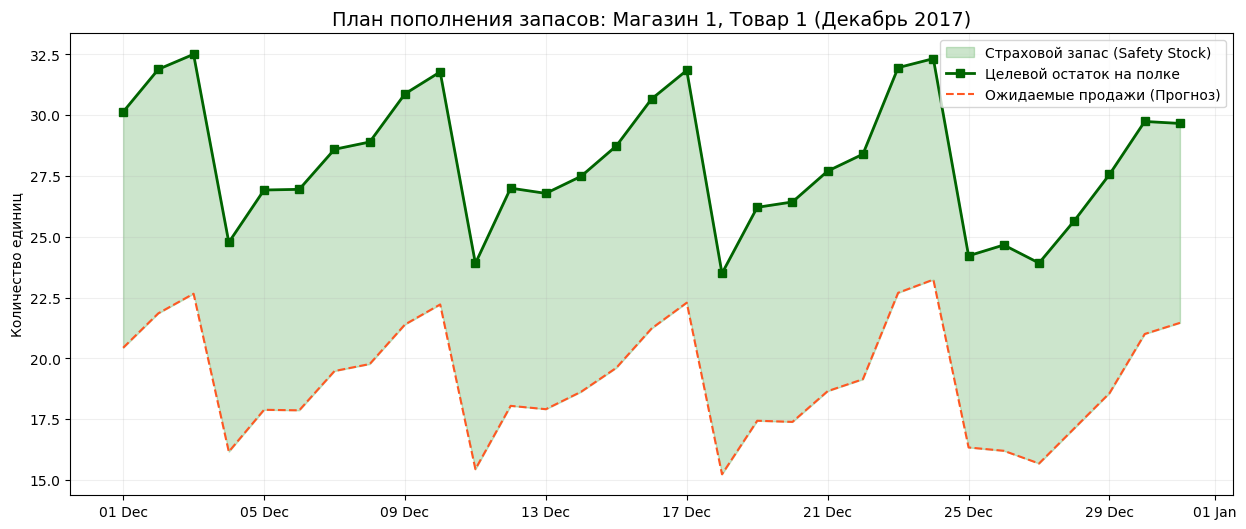

In [34]:
# Выберем топ-товар для примера
s, i = 1, 1
plan = forecast_df[(forecast_df["store"] == s) & (forecast_df["item"] == i)].sort_values("date")

plt.figure(figsize=(15, 6))

# Заливка: Зона страхового запаса (Safety Stock)
plt.fill_between(plan["date"], plan["predicted_sales"], plan["upper_ci"], 
                 color='green', alpha=0.2, label="Страховой запас (Safety Stock)")

# Линия: Необходимый остаток на начало дня
plt.plot(plan["date"], plan["upper_ci"], color='darkgreen', marker='s', lw=2, label="Целевой остаток на полке")

# Линия: Ожидаемые продажи
plt.plot(plan["date"], plan["predicted_sales"], color='#FF5722', ls='--', label="Ожидаемые продажи (Прогноз)")

plt.title(f"План пополнения запасов: Магазин {s}, Товар {i} (Декабрь 2017)", fontsize=14)
plt.ylabel("Количество единиц")
plt.legend()
plt.grid(True, alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.show()

In [35]:
# 1. Группируем
purchase_order = forecast_df.groupby(["store", "item"]).agg({
    "predicted_sales": "sum",
    "upper_ci": "sum"
}).reset_index()

# 2. Считаем дополнительные поля
purchase_order["order_volume"] = np.ceil(purchase_order["upper_ci"]).astype(int)
purchase_order["predicted_sales_int"] = np.ceil(purchase_order["predicted_sales"]).astype(int)
purchase_order["safety_buffer"] = purchase_order["order_volume"] - purchase_order["predicted_sales_int"]

# 3. Переименовываем только нужные нам колонки
rename_dict = {
    "store": "Магазин",
    "item": "Товар",
    "predicted_sales_int": "Прогноз продаж",
    "order_volume": "Рекомендуемый закуп",
    "safety_buffer": "Страховой запас"
}

# Оставляем только финальный набор колонок в нужном порядке
final_table = purchase_order[list(rename_dict.keys())].rename(columns=rename_dict)

# 5. Вывод
print("ТОП-10 ПОЗИЦИЙ ДЛЯ ЗАКУПКИ НА ДЕКАБРЬ:")
print(final_table.sort_values("Рекомендуемый закуп", ascending=False).head(10).to_string(index=False))

ТОП-10 ПОЗИЦИЙ ДЛЯ ЗАКУПКИ НА ДЕКАБРЬ:
 Магазин  Товар  Прогноз продаж  Рекомендуемый закуп  Страховой запас
       2     28            2824                 3336              512
       2     15            2810                 3320              510
       2     18            2748                 3281              533
       8     15            2712                 3261              549
       2     13            2716                 3252              536
       8     28            2715                 3244              529
       2     45            2696                 3233              537
       3     15            2688                 3233              545
       2     22            2680                 3232              552
       2     25            2685                 3226              541
